# Normalization
Here I study the effect of LayerNorm, Pre LN, Post LN, Batch Norm and RMS Norm on a transformer and its task of language modeling.

[Link of my notes](https://spurious-ruby-475.notion.site/LLMs-3299a03e8f30802ba3c7e182f23f8e7e#3459a03e8f3080fda536ca89f83af9f6)

In [56]:
from typing import List, Tuple
from transformers import AutoTokenizer
import torch.nn as nn
import torch

tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

# load the dataset
DATASET_PATH = "../data/lm.txt"
texts = None

with open(DATASET_PATH, "r") as file:
    texts = file.readlines()

_token_lists = tokenizer(texts)["input_ids"]
tokenized = [tid for line in _token_lists for tid in line]

def build_sequences(token_ids: List[int], seq_len: int) -> Tuple[torch.Tensor, torch.Tensor]:
    inputs = []
    targets = []

    for i in range(len(token_ids) - seq_len):
        x = token_ids[i:i+seq_len]
        y = token_ids[i+1:i+seq_len+1]
        inputs.append(x)
        targets.append(y)

    return torch.tensor(inputs), torch.tensor(targets)

inputs, targets = build_sequences(tokenized, seq_len=128)

In [57]:
from torch.utils.data import Dataset, DataLoader

class LMDataset(Dataset):
    def __init__(self, inputs: torch.Tensor, targets: torch.Tensor) -> None:
        self.inputs = inputs
        self.targets = targets

    def __len__(self) -> int:
        return len(self.inputs)

    def __getitem__(self, idx: int) -> dict:
        return {
            "input_ids": self.inputs[idx],
            "labels": self.targets[idx]
        }

def create_dataloader(dataset: Dataset, batch_size: int = 16, shuffle: bool = True) -> DataLoader:
    return DataLoader(dataset=dataset, batch_size=batch_size, shuffle=shuffle)

dataset = LMDataset(inputs=inputs, targets=targets)
_n = len(dataset)
_n_val = max(1, _n // 10)
_g = torch.Generator().manual_seed(42)
train_dataset, val_dataset = torch.utils.data.random_split(
    dataset, [_n - _n_val, _n_val], generator=_g
)
train_loader = create_dataloader(dataset=train_dataset, batch_size=16, shuffle=True)
val_loader = create_dataloader(dataset=val_dataset, batch_size=16, shuffle=False)
data_loader = train_loader

In [58]:


class LayerNorm(nn.Module):
    def __init__(self, model_dimension: int, epsilon: float = 1e-5) -> None:
        super().__init__()
        self.gamma = nn.Parameter(torch.ones(model_dimension))
        self.beta = nn.Parameter(torch.zeros(model_dimension))
        self.epsilon = epsilon

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        mu = x.mean(dim=-1, keepdim=True)
        var = (x - mu).pow(2).mean(dim=-1, keepdim=True)
        x_scaled = (x - mu) / torch.sqrt(var + self.epsilon)
        return self.gamma * x_scaled + self.beta

class BatchNorm(nn.Module):
    def __init__(self, model_dimension: int) -> None:
        super().__init__()
        self.bn = nn.BatchNorm1d(model_dimension)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.bn(x.transpose(-2, -1)).transpose(-2, -1)

class RMSNorm(nn.Module):
    def __init__(self, model_dimension: int) -> None:
        super().__init__()
        self.gamma = nn.Parameter(torch.ones(model_dimension))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        rms = torch.sqrt(x.pow(2).mean(dim=-1, keepdim=True) + 1e-5)
        return x / rms * self.gamma


class ResidualBlock(nn.Module):
    def __init__(self, model_dimension: int, method: str) -> None:
        super().__init__()
        self.model_dimension = model_dimension
        self.is_identity = method == "id"
        if self.is_identity:
            self.normalizer = nn.Identity()
            self.location = "pre"
            return
        parts = method.split("_")
        if len(parts) == 1:
            self.location = "pre"
            norm_kind = parts[0]
        else:
            self.location = parts[0]
            norm_kind = parts[1]
        if norm_kind == "ln":
            self.normalizer = LayerNorm(model_dimension=model_dimension)
        elif norm_kind == "bn":
            self.normalizer = BatchNorm(model_dimension=model_dimension)
        elif norm_kind == "rms":
            self.normalizer = RMSNorm(model_dimension=model_dimension)
        else:
            raise ValueError(method)

    def forward(self, x_id: torch.Tensor, x: torch.Tensor) -> torch.Tensor:
        if self.is_identity:
            return x_id + x
        if self.location == "pre":
            return x_id + self.normalizer(x)
        return self.normalizer(x_id + x)

class Transformer(nn.Module):
    def __init__(
        self, 
        model_dimension: int, 
        hidden_dimension: int, 
        num_heads: int, 
        vocabulary_size: int,
        method: str
    ) -> None:
        super().__init__()
        self.model_dimension = model_dimension
        self.embedding = nn.Embedding(num_embeddings=vocabulary_size, embedding_dim=model_dimension)
        self.mha = nn.MultiheadAttention(embed_dim=model_dimension, num_heads=num_heads, batch_first=True)
        self.norm_1 = ResidualBlock(model_dimension=model_dimension, method=method)
        
        self.ff = nn.Sequential(
            nn.Linear(in_features=model_dimension, out_features=hidden_dimension),
            nn.ReLU(),
            nn.Dropout(),
            nn.Linear(in_features=hidden_dimension, out_features=model_dimension)
        )

        self.norm_2 = ResidualBlock(model_dimension=model_dimension, method=method)
        self.out = nn.Linear(in_features=model_dimension, out_features=vocabulary_size)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.embedding(x)
        x_id = x
        s = x.size(1)
        attn_mask = torch.triu(torch.ones(s, s, device=x.device, dtype=torch.bool), diagonal=1)
        x, _ = self.mha(x, x, x, attn_mask=attn_mask)
        x = self.norm_1(x_id, x)
        x_id = x
        x = self.ff(x)
        x = self.norm_2(x_id, x)

        return self.out(x)

Epoch 1/3, Loss: 1.827153205871582
Epoch 2/3, Loss: 1.0171449184417725
Epoch 3/3, Loss: 0.5929093956947327
val_loss=0.480421
'Rivers flow' -> "rivers flow. scale determines how much detail a map can show. topographic maps display elevation and landforms. time zones divide the earth ' s axis. the longest and landforms. the longest and land"
'The Nile River' -> 'the nile river. the earth. the equinox occurs when day and night cycles. tourism can influence local economies of the longest and night cycles. human settlements often form near reliable water sources. human settlements'
'Mountains are formed' -> 'mountains are formed is stored beneath the environment significantly. scale determines how much detail a vast diversity of the largest hot deserts on earth. scale determines how many countries. scale determines how much detail a map can show. topographic'


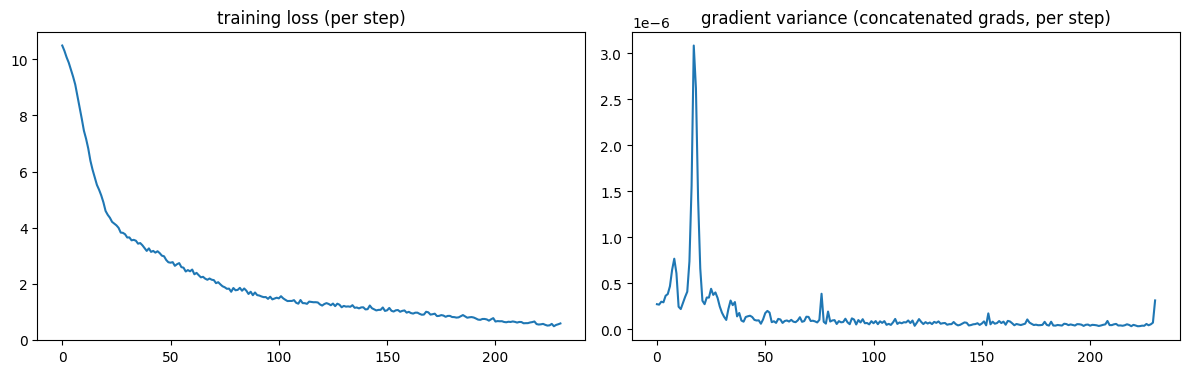

In [59]:
from typing import List

import matplotlib.pyplot as plt
import torch.nn.functional as F

class Trainer:
    def __init__(self, model: nn.Module, device: str = "mps") -> None:
        self.model = model
        self.device = device
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=0.001)
        self.loss_history = []
        self.gradients_variance_history = []

    def get_gradients_variance(self) -> float:
        parts = [p.grad.detach().reshape(-1) for p in self.model.parameters() if p.grad is not None]
        if not parts:
            return float("nan")
        g = torch.cat(parts)
        return g.var(unbiased=False).item()

    def train(self, data_loader: DataLoader, num_epochs: int = 10) -> None:
        self.model.to(self.device)

        for epoch in range(num_epochs):
            self.model.train()
            for batch in data_loader:
                inputs = batch["input_ids"].to(self.device)
                targets = batch["labels"].to(self.device)
                
                outputs = self.model(inputs)
                loss = F.cross_entropy(outputs.transpose(1, 2), targets)

                self.optimizer.zero_grad()
                loss.backward()
                self.gradients_variance_history.append(self.get_gradients_variance())
                self.optimizer.step()

                self.loss_history.append(loss.item())

            print(f"Epoch {epoch+1}/{num_epochs}, Loss: {loss.item()}")

        return self.loss_history


@torch.inference_mode()
def evaluate_lm(model: nn.Module, data_loader: DataLoader, device: str) -> float:
    model.eval()
    total = 0.0
    n = 0
    for batch in data_loader:
        inputs = batch["input_ids"].to(device)
        targets = batch["labels"].to(device)
        outputs = model(inputs)
        loss = F.cross_entropy(outputs.transpose(1, 2), targets, reduction="sum")
        total += loss.item()
        n += int(targets.numel())
    return total / max(n, 1)


@torch.inference_mode()
def demo_generation(
    model: nn.Module,
    tokenizer,
    device: str,
    prompts: List[str],
    max_new_tokens: int = 48,
) -> None:
    model.eval()
    for prompt in prompts:
        enc = tokenizer(prompt, add_special_tokens=False, return_tensors="pt")
        out_ids = enc["input_ids"].to(device)
        if out_ids.size(1) == 0:
            out_ids = torch.zeros(1, 1, dtype=torch.long, device=device)
        for _ in range(max_new_tokens):
            logits = model(out_ids)
            nxt = logits[:, -1, :].argmax(dim=-1, keepdim=True)
            out_ids = torch.cat([out_ids, nxt], dim=1)
        text = tokenizer.decode(out_ids[0].tolist(), skip_special_tokens=True)
        print(f"{prompt!r} -> {text!r}")


NUM_EPOCHS = 3

transformer = Transformer(model_dimension=128, hidden_dimension=256, num_heads=4, vocabulary_size=tokenizer.vocab_size, method="id")
trainer = Trainer(model=transformer, device="mps")
trainer.train(data_loader=train_loader, num_epochs=NUM_EPOCHS)

val_loss = evaluate_lm(trainer.model, val_loader, trainer.device)
print(f"val_loss={val_loss:.6f}")

demo_generation(
    trainer.model,
    tokenizer,
    trainer.device,
    prompts=["Rivers flow", "The Nile River", "Mountains are formed"],
)

def plot_loss_and_grad_variance(trainer: Trainer) -> None:  
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(trainer.loss_history)
    axes[0].set_title("training loss (per step)")
    axes[1].plot(trainer.gradients_variance_history)
    axes[1].set_title("gradient variance (concatenated grads, per step)")
    plt.tight_layout()
    plt.show()

plot_loss_and_grad_variance(trainer)

Epoch 1/3, Loss: 0.8473432660102844
Epoch 2/3, Loss: 0.19701743125915527
Epoch 3/3, Loss: 0.07842246443033218
val_loss=0.092250
'Rivers flow' -> 'rivers flow into electrical power. hydropower uses flowing water to generate electricity. solar energy is captured from sunlight using panels. wind farms convert air movement into electrical power. cultural landscapes reflect human interaction with the environment.'
'The Nile River' -> "the nile river. the amazon river carries more water than any other river. mountains are formed by tectonic forces beneath the earth ' s crust. the himalayas contain some of the highest peaks in the world. mount"
'Mountains are formed' -> 'mountains are formed.s are flat areas of land at high elevation. valleys are low areas between hills or mountains. erosion wears away rocks and soil over time. deposition builds up layers of sediment in new locations.'


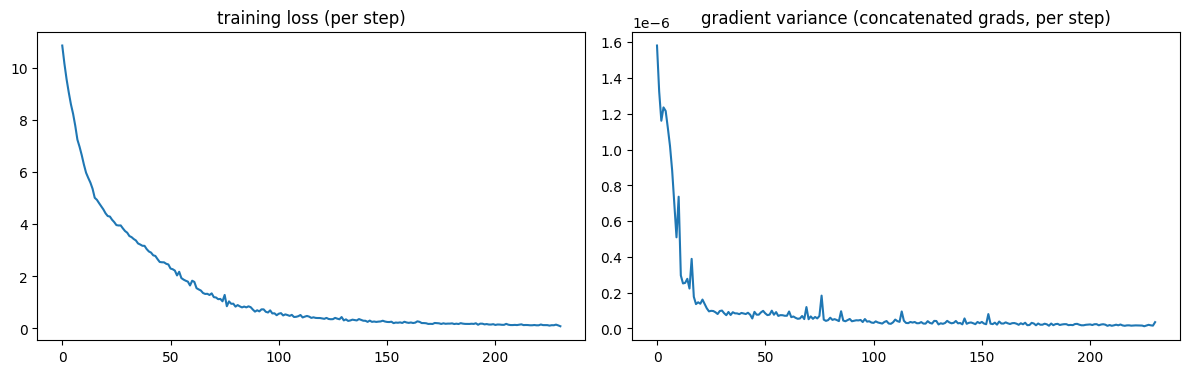

In [60]:
transformer = Transformer(model_dimension=128, hidden_dimension=256, num_heads=4, vocabulary_size=tokenizer.vocab_size, method="pre_ln")
trainer = Trainer(model=transformer, device="mps")
trainer.train(data_loader=train_loader, num_epochs=NUM_EPOCHS)

val_loss = evaluate_lm(trainer.model, val_loader, trainer.device)
print(f"val_loss={val_loss:.6f}")

demo_generation(
    trainer.model,
    tokenizer,
    trainer.device,
    prompts=["Rivers flow", "The Nile River", "Mountains are formed"],
)

def plot_loss_and_grad_variance(trainer: Trainer) -> None:  
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(trainer.loss_history)
    axes[0].set_title("training loss (per step)")
    axes[1].plot(trainer.gradients_variance_history)
    axes[1].set_title("gradient variance (concatenated grads, per step)")
    plt.tight_layout()
    plt.show()

plot_loss_and_grad_variance(trainer)

Epoch 1/3, Loss: 2.430269479751587
Epoch 2/3, Loss: 0.9347087740898132
Epoch 3/3, Loss: 0.3414970934391022
val_loss=0.369018
'Rivers flow' -> "rivers flow from sunlight using panels. satellites provide images of the earth ' s surface from space. the pacific ocean is the largest ocean is the largest ocean on the largest ocean on the largest ocean on the largest ocean on the largest ocean"
'The Nile River' -> 'the nile river. continents are formed by moving tectonic plates. population density measures how many people live in an area. cities develop near resources like rivers, and fertile land. agriculture depends on most sides.'
'Mountains are formed' -> "mountains are formed by moving tectonic plates. the earth ' s surface. the pacific ocean is the largest hot deserts receive very little rainfall throughout the largest hot deserts on earth. continents are dense forests found in an area."


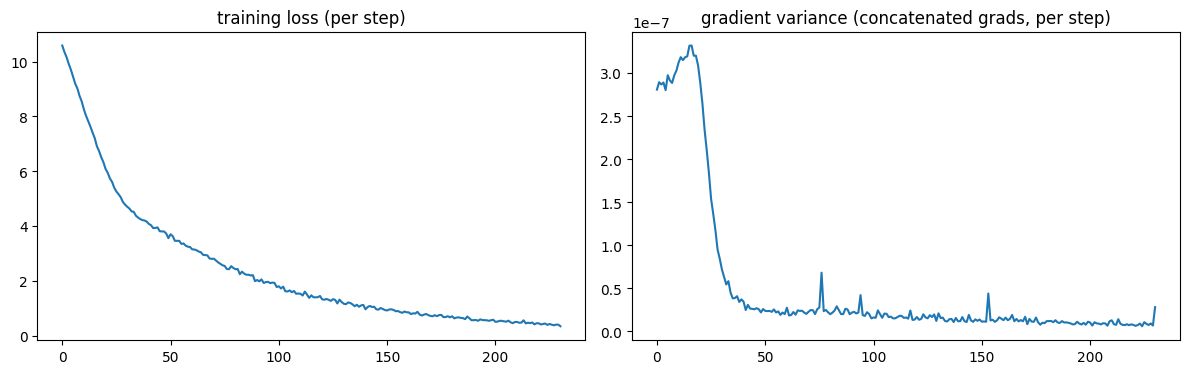

In [61]:
transformer = Transformer(model_dimension=128, hidden_dimension=256, num_heads=4, vocabulary_size=tokenizer.vocab_size, method="post_ln")
trainer = Trainer(model=transformer, device="mps")
trainer.train(data_loader=train_loader, num_epochs=NUM_EPOCHS)

val_loss = evaluate_lm(trainer.model, val_loader, trainer.device)
print(f"val_loss={val_loss:.6f}")

demo_generation(
    trainer.model,
    tokenizer,
    trainer.device,
    prompts=["Rivers flow", "The Nile River", "Mountains are formed"],
)

def plot_loss_and_grad_variance(trainer: Trainer) -> None:  
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(trainer.loss_history)
    axes[0].set_title("training loss (per step)")
    axes[1].plot(trainer.gradients_variance_history)
    axes[1].set_title("gradient variance (concatenated grads, per step)")
    plt.tight_layout()
    plt.show()

plot_loss_and_grad_variance(trainer)

Epoch 1/3, Loss: 3.0773849487304688
Epoch 2/3, Loss: 1.0258210897445679
Epoch 3/3, Loss: 0.5796335339546204
val_loss=0.416536
'Rivers flow' -> 'rivers flow and night cycles. estuaries are areas that are areas that are areas that are areas that are areas that are areas that are areas that are areas that are areas that are areas that are areas that are areas that are areas that are'
'The Nile River' -> "the nile river. the earth ' s surface. the amazon rainforests are large landmasses separated by oceans. the amazon rainforest contains a vast diversity of fire surrounds the pacific ocean is the largest and most populous continent."
'Mountains are formed' -> 'mountains are formed by tectonic plates. fault lines mark the year. population density measures how many people live in an area. urban areas have higher population density than rural areas. cities develop near resources like water and'


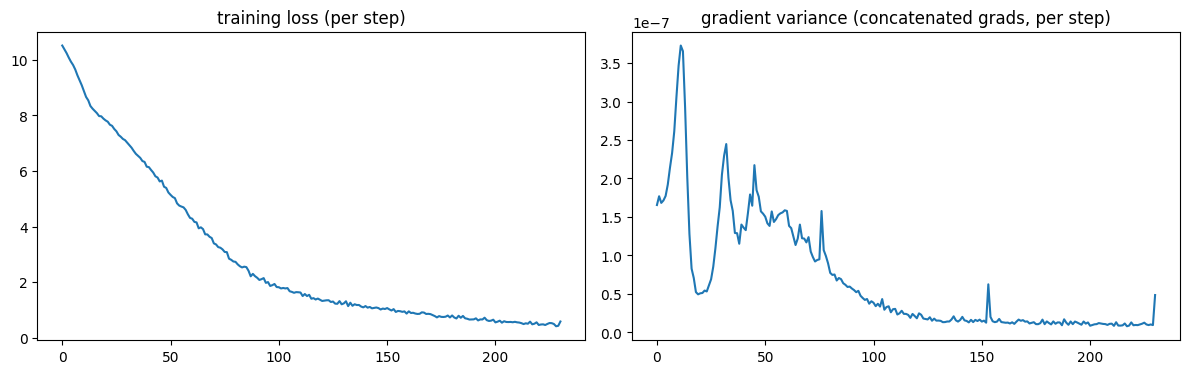

In [62]:
transformer = Transformer(model_dimension=128, hidden_dimension=256, num_heads=4, vocabulary_size=tokenizer.vocab_size, method="post_bn")
trainer = Trainer(model=transformer, device="mps")
trainer.train(data_loader=train_loader, num_epochs=NUM_EPOCHS)

val_loss = evaluate_lm(trainer.model, val_loader, trainer.device)
print(f"val_loss={val_loss:.6f}")

demo_generation(
    trainer.model,
    tokenizer,
    trainer.device,
    prompts=["Rivers flow", "The Nile River", "Mountains are formed"],
)

def plot_loss_and_grad_variance(trainer: Trainer) -> None:  
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(trainer.loss_history)
    axes[0].set_title("training loss (per step)")
    axes[1].plot(trainer.gradients_variance_history)
    axes[1].set_title("gradient variance (concatenated grads, per step)")
    plt.tight_layout()
    plt.show()

plot_loss_and_grad_variance(trainer)

Epoch 1/3, Loss: 2.7245967388153076
Epoch 2/3, Loss: 0.957611083984375
Epoch 3/3, Loss: 0.4159022569656372
val_loss=0.422003
'Rivers flow' -> "rivers flow earth ' s surface. renewable resources power industries and homes. hydropower uses flowing water to generate electricity. solar energy is captured from sunlight using panels. wind farms convert air movement into electrical power."
'The Nile River' -> 'the nile river carries. mount everest is the largest and most populous continent. glaciers are large masses of climates and driest continent. glaciers are large masses of climates and ecosystems. glaciers are large masses of climates and ecosystems'
'Mountains are formed' -> "mountains are formed by frozen for most of the earth ' s surface. the pacific ocean on the pacific ocean on the pacific ocean on the pacific ocean on the pacific ocean on the pacific ocean on the pacific ocean on the pacific ocean on the pacific ocean"


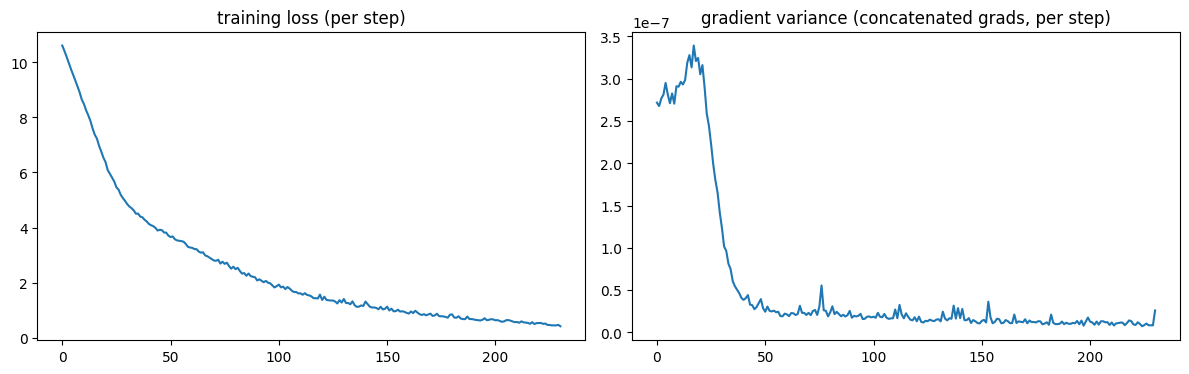

In [63]:
transformer = Transformer(model_dimension=128, hidden_dimension=256, num_heads=4, vocabulary_size=tokenizer.vocab_size, method="post_rms")
trainer = Trainer(model=transformer, device="mps")
trainer.train(data_loader=train_loader, num_epochs=NUM_EPOCHS)

val_loss = evaluate_lm(trainer.model, val_loader, trainer.device)
print(f"val_loss={val_loss:.6f}")

demo_generation(
    trainer.model,
    tokenizer,
    trainer.device,
    prompts=["Rivers flow", "The Nile River", "Mountains are formed"],
)

def plot_loss_and_grad_variance(trainer: Trainer) -> None:  
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(trainer.loss_history)
    axes[0].set_title("training loss (per step)")
    axes[1].plot(trainer.gradients_variance_history)
    axes[1].set_title("gradient variance (concatenated grads, per step)")
    plt.tight_layout()
    plt.show()

plot_loss_and_grad_variance(trainer)